In [1]:
#pip install pyomyo

In [1]:
import time
from libemg.streamers import myo_streamer
from libemg.data_handler import OnlineDataHandler

def main():
    streamer, shared_memory = myo_streamer(emg=True, imu=True, filtered=False)
    odh = OnlineDataHandler(shared_memory_items=shared_memory)
    odh.reset()

    start_time = time.time()  # inizializza timestamp zero all'inizio
    
    try:
        while True:
            data, _ = odh.get_data(N=50, filter=False)  # prendi 50 campioni
            
            current_time = time.time()
            elapsed_ms = int((current_time - start_time) * 1000)  # tempo passato in ms
            
            emg_samples = len(data['emg']) if 'emg' in data else 0
            imu_samples = len(data['imu']) if 'imu' in data else 0

            
            '''if emg_samples > 0:
                first_emg = data['emg'][0]
                print(f"Elapsed time: {elapsed_ms} ms, EMG samples: {emg_samples}, first EMG sample: {first_emg}")
            else:
                print("Waiting for EMG data...")
            
            if imu_samples > 0:
                first_imu = data['imu'][0]
                print(f"Elapsed time: {elapsed_ms} ms, IMU samples: {imu_samples}, first IMU sample: {first_imu}")
            else:
                print("Waiting for IMU data...")'''
            
            time.sleep(0.05)

    except KeyboardInterrupt:
        print("Stopped by user")
    finally:
        streamer.stop()

if __name__ == "__main__":
    main()

Not finding key emg in shared memory...waiting.
Stopped by user


AttributeError: 'MyoStreamer' object has no attribute 'stop'

In [2]:
import time
from libemg.streamers import myo_streamer
from libemg.data_handler import OnlineDataHandler

def main():
    streamer, shared_memory = myo_streamer(emg=True, imu=True, filtered=False)
    odh = OnlineDataHandler(shared_memory_items=shared_memory)
    odh.reset()

    start_time = time.time()  # inizializza timestamp zero all'inizio

    try:
        while True:
            data, _ = odh.get_data(N=50, filter=False)  # prendi 50 campioni
            
            current_time = time.time()
            elapsed_ms = int((current_time - start_time) * 1000)  # tempo passato in ms
            
            if 'emg' in data and len(data['emg']) > 0:
                first_emg = data['emg'][0]  # primo campione EMG del batch
                print(f"Elapsed time: {elapsed_ms} ms, EMG first sample: {first_emg}")
            else:
                print("Waiting for EMG data...")
            
            if 'imu' in data and len(data['imu']) > 0:
                first_imu = data['imu'][0]  # primo campione IMU del batch
                print(f"Elapsed time: {elapsed_ms} ms, IMU first sample: {first_imu}")
            else:
                print("Waiting for IMU data...")
            
            time.sleep(0.05)

    except KeyboardInterrupt:
        print("Stopped by user")
    finally:
        streamer.stop()

if __name__ == "__main__":
    main()

Elapsed time: 0 ms, EMG first sample: [0. 0. 0. 0. 0. 0. 0. 0.]
Elapsed time: 0 ms, IMU first sample: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Elapsed time: 51 ms, EMG first sample: [  1.  -3.   6.  -4. -10.   2.  -2.  -1.]
Elapsed time: 51 ms, IMU first sample: [ 1.0205e+04 -1.3090e+03 -5.4610e+03  1.1521e+04  6.2000e+02 -1.1460e+03
  1.5390e+03 -1.1000e+01  2.3000e+01  3.3000e+01]
Elapsed time: 107 ms, EMG first sample: [-1. -1.  1. -4. -5.  3.  2.  2.]
Elapsed time: 107 ms, IMU first sample: [10198. -1333. -5455. 11527.   604. -1156.  1549.   -15.    45.    32.]
Elapsed time: 159 ms, EMG first sample: [ 1. -4.  3. -5. -9.  1. -2. -3.]
Elapsed time: 159 ms, IMU first sample: [ 1.0195e+04 -1.3610e+03 -5.4440e+03  1.1532e+04  5.8900e+02 -1.1650e+03
  1.5520e+03 -1.1000e+01  3.7000e+01  2.2000e+01]
Elapsed time: 209 ms, EMG first sample: [-4.  0.  4.  4. -6.  0. -3. -4.]
Elapsed time: 209 ms, IMU first sample: [10193. -1373. -5442. 11534.   592. -1162.  1557.   -16.    18.    15.]
Elapsed time: 

AttributeError: 'MyoStreamer' object has no attribute 'stop'

Plotting at t = 10.00 s


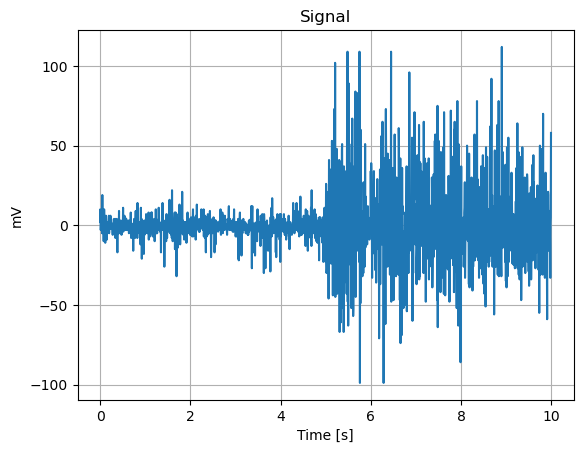

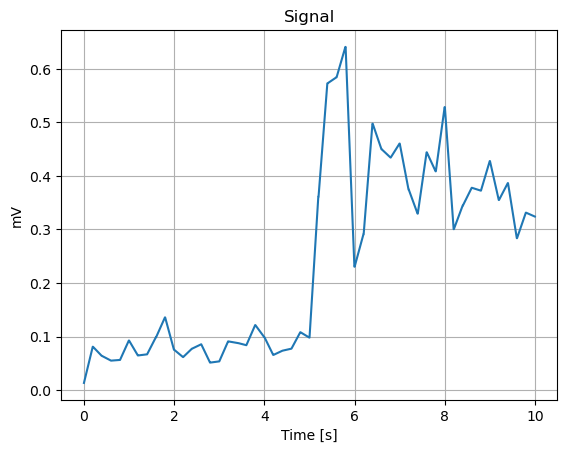

Plotting at t = 20.00 s


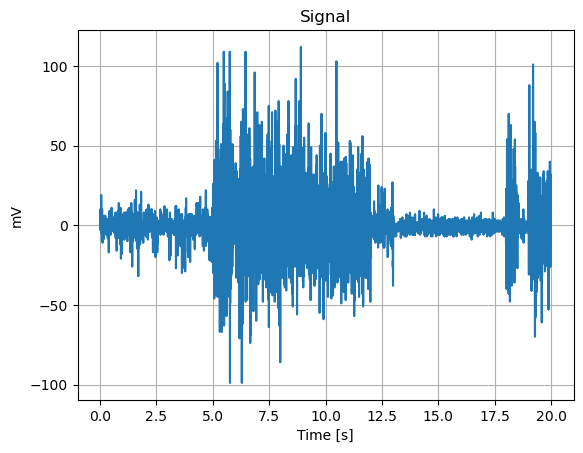

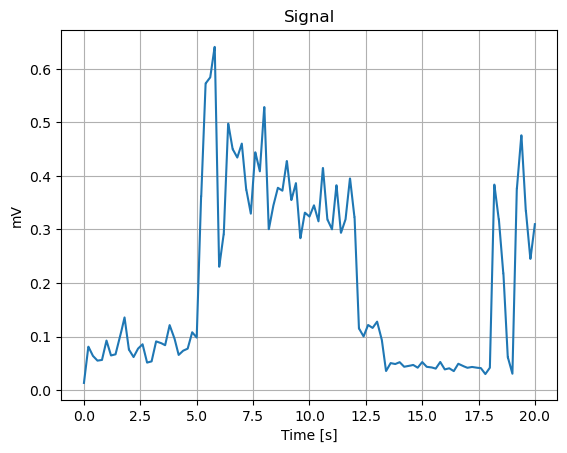

Plotting at t = 29.99 s


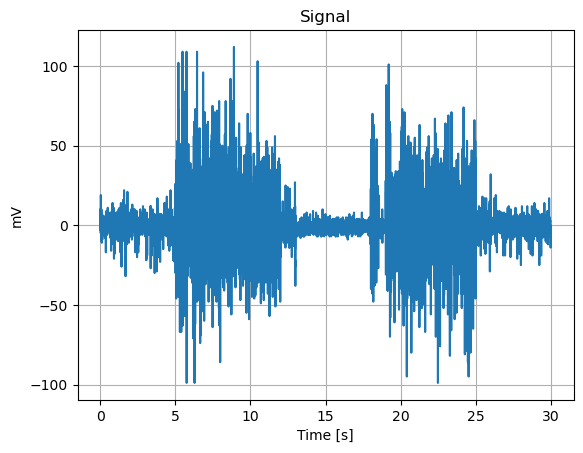

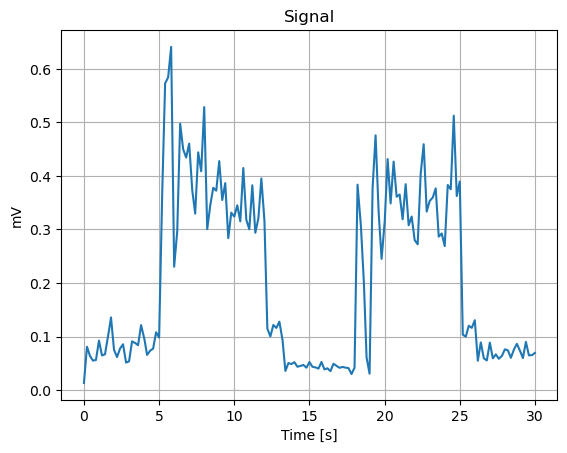

Stopped by user


In [3]:
import time
import matplotlib.pyplot as plt
from libemg.streamers import myo_streamer
from libemg.data_handler import OnlineDataHandler
import numpy as np
import sys
sys.path.append('../lib')
from emg_utils import bandpass_filter,rectification, RMS_moving, MVC_normalization, plot_emg_signal

def main():
    streamer, shared_memory = myo_streamer(emg=True, imu=True, filtered=False)
    odh = OnlineDataHandler(shared_memory_items=shared_memory)
    odh.reset()

    fs = 200
    dt = 1 / fs
    emg_signal = np.array([])  # segnale EMG cumulativo
    emg_time = np.array([])    # vettore tempo cumulativo
    last_plot_time = time.time()  # timestamp dell'ultimo plot
    plot_interval = 10.0  # ogni 4 secondi
    muscle_name = 'channel_7'
    # Inizia a loggare su file
    '''odh.log_to_file(
        block=False,
        file_path="session2_data",   # Genererà session1_data_emg.csv e session1_data_imu.csv
        timestamps=False
    )'''
    mvc = '../data/mvc_values/myo/S01_05_26/combined_dataset.csv'
    start_time = time.time()
    try:
        time.sleep(1)
        while True:
            data, _ = odh.get_data(N=200, filter=False)
            current_time = time.time()
            elapsed_ms = int((current_time - start_time) * 1000)

            if 'emg' in data and len(data['emg']) > 0:
                new_emg = data['emg'][:, 6]  # prendi il canale 6 (indice 5)
                # Estendi il segnale cumulativo con i nuovi dati
                emg_signal = np.concatenate((emg_signal, new_emg))
                
                # Calcola i nuovi tempi partendo dall'ultimo valore di emg_time (o zero se vuoto)
                if emg_time.size == 0:
                    last_time = 0
                else:
                    last_time = emg_time[-1] + dt
                
                new_times = np.arange(last_time, last_time + dt * len(new_emg), dt)
                
                emg_time = np.concatenate((emg_time, new_times))
                # Ora elaborazioni su tutto il segnale cumulativo
                emg_filtered = bandpass_filter(emg_signal, fs, high_freq=99)
                emg_rectified = rectification(emg_filtered)
                emg_rms = RMS_moving(emg_rectified, fs)
                emg_normalized = MVC_normalization(emg_rms, muscle_name, mvc)

                # PLOT ogni 4 secondi
                now = time.time()
                if now - last_plot_time >= plot_interval:
                    print(f"Plotting at t = {emg_time[-1]:.2f} s")
                    plot_emg_signal(emg_signal, emg_time)
                    plot_emg_signal(emg_normalized, emg_time)
                    last_plot_time = now

            else:
                print("Waiting for EMG data...")

            if 'imu' in data and len(data['imu']) > 0:
                first_imu = data['imu'][0]
                #print(f"Elapsed time: {elapsed_ms} ms, IMU first sample: {first_imu}")
            else:
                print("Waiting for IMU data...")

            time.sleep(1)

    except KeyboardInterrupt:
        odh.stop_all()
        print("Stopped by user")

if __name__ == "__main__":
    main()

In [46]:
import time
import matplotlib.pyplot as plt
from libemg.streamers import myo_streamer
from libemg.data_handler import OnlineDataHandler
import numpy as np
import sys
sys.path.append('../lib')
from emg_utils import bandpass_filter,rectification, RMS_moving, MVC_normalization, plot_emg_signal

def main():
    streamer, shared_memory = myo_streamer(emg=True, imu=True, filtered=False)
    odh = OnlineDataHandler(shared_memory_items=shared_memory)
    odh.reset()

    fs = 200
    dt = 1 / fs
    emg_signal = np.array([])  # segnale EMG cumulativo
    emg_time = np.array([]) # vettore tempo cumulativo
    last_emg = np.array([]) # vettore tempo cumulativo
    muscle_name = 'channel_7'
    last_milestone = 0
    # Inizia a loggare su file
    '''odh.log_to_file(
        block=False,
        file_path="session2_data",   # Genererà session1_data_emg.csv e session1_data_imu.csv
        timestamps=False
    )'''
    mvc = '../data/mvc_values/myo/S01_05_26/combined_dataset.csv'
    start_time = time.time()
    try:
        time.sleep(0.5)
        last_plot_time = time.time()  # timestamp dell'ultimo plot
        while True:
            data, _ = odh.get_data(N=40, filter=False)
            current_time = time.time()
            elapsed_ms = int((current_time - start_time) * 1000)

            if 'emg' in data and len(data['emg']) > 0:
                new_emg = data['emg'][:, 6]  # prendi il canale 6 (indice 5)

                max_overlap = min(len(last_emg), len(new_emg))
                
                overlap_len = 0
                for ol in range(max_overlap, 0, -1):
                    if np.allclose(last_emg[-ol:], new_emg[:ol], atol=1e-7):
                        overlap_len = ol
                        print(f"Overlap di {ol}")
                        break
                                    
                last_emg = new_emg
                if overlap_len > 0:
                    new_emg = new_emg[overlap_len:]  # Rimuovi i valori duplicati all'inizio di new_emg
                    
                # Aggiungi solo i valori di new_emg dopo l'overlap
                if len(new_emg) > 0:
                    emg_signal = np.concatenate((emg_signal, new_emg))
                #emg_signal = np.concatenate((emg_signal, new_emg))

                print(len(emg_signal))
                # Calcola i nuovi tempi partendo dall'ultimo valore di emg_time (o zero se vuoto)
                if emg_time.size == 0:
                    last_time = 0
                else:
                    last_time = emg_time[-1] + dt
                
                new_times = np.linspace(last_time, last_time + dt * (len(new_emg)-1), len(new_emg))
                emg_time = np.concatenate((emg_time, new_times))
                
                # Ora elaborazioni su tutto il segnale cumulativo
                emg_filtered = bandpass_filter(emg_signal, fs, high_freq=99)
                emg_rectified = rectification(emg_filtered)
                emg_rms = RMS_moving(emg_rectified, fs)
                emg_normalized = MVC_normalization(emg_rms, muscle_name, mvc)

                current_length = len(emg_signal)
                current_milestone = (current_length // 1000) * 1000
                
                if current_milestone > last_milestone:
                    plot_emg_signal(emg_signal, emg_time)
                    plot_emg_signal(emg_normalized, emg_time)
                    last_milestone = current_milestone

            else:
                print("Waiting for EMG data...")

            if 'imu' in data and len(data['imu']) > 0:
                first_imu = data['imu'][0]
                #print(f"Elapsed time: {elapsed_ms} ms, IMU first sample: {first_imu}")
            else:
                print("Waiting for IMU data...")


    except KeyboardInterrupt:
        odh.stop_all()
        print("Stopped by user")

if __name__ == "__main__":
    main()

10


IndexError: list index out of range